<a href="https://colab.research.google.com/github/nsremonethaji18-sys/Content-Monetization-Modeler/blob/main/amazon_music_clustering_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving single_genre_artists.csv to single_genre_artists (4).csv
                 id_songs         name_song  popularity_songs  duration_ms  \
0  0IA0Hju8CAgYfV1hwhidBH           La Java                 0       161427   
1  1b8HZQCqcqwbzlA1jRTp6E          En Douce                 0       223440   
2  5d5gQxHwYovxR5pqETOIAa     J'en Ai Marre                 0       208267   
3  1EO65UEEPfy7CR0NK2sDxy  Ils n'ont pas ca                 0       161933   
4  6a58gXSgqbIsXUhVZ6ZJqe         La belote                 0       167973   

   explicit              id_artists release_date  danceability  energy  key  \
0         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.563   0.184    4   
1         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.427   0.180   10   
2         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.511   0.206    0   
3         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.676   0.467    9   
4         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.650   0.298  

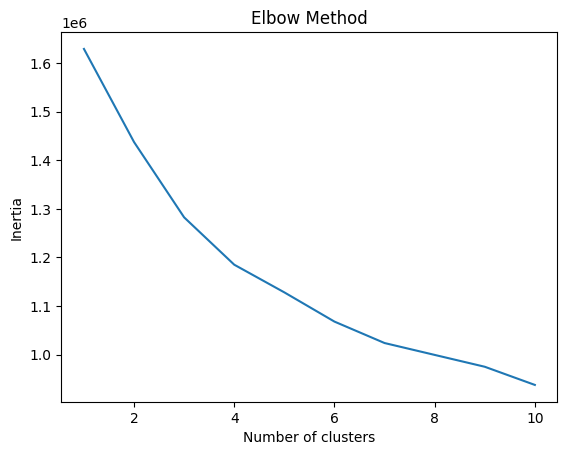

Silhouette Score: 0.12356276235625095


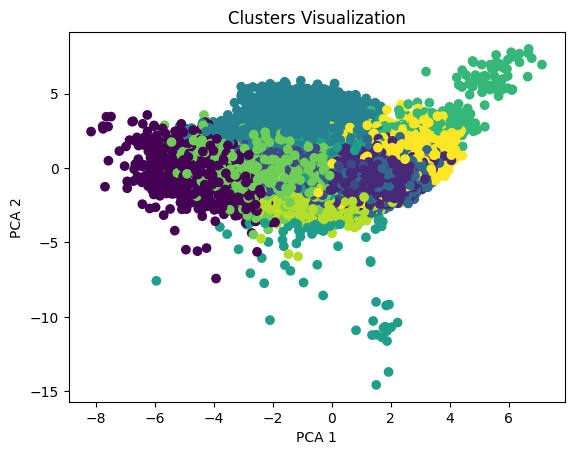

         popularity_songs    duration_ms  explicit  danceability    energy  \
Cluster                                                                      
0               17.764765  212159.820832  0.000000      0.399480  0.201902   
1               32.069140  227368.428150  0.000000      0.620091  0.710664   
2               11.591215  180831.099830  0.000000      0.642247  0.425029   
3               31.748640  233611.212091  0.000000      0.629326  0.695269   
4               29.867918   86075.700930  0.000000      0.664869  0.475612   
5               21.404981  328287.989442  0.001624      0.509773  0.639866   
6               43.171160  240069.284639  0.060188      0.559732  0.551496   
7               23.188849  229331.727273  0.000000      0.448882  0.300838   
8               15.587711  239404.265060  0.000000      0.580992  0.665801   
9               40.567360  206105.203724  1.000000      0.687907  0.682271   

              key   loudness      mode  speechiness  acousticne

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('/content/single_genre_artists.csv')

print(df.head())
print(df.info())

df = df.drop(['track_id','track_name','artist_name'], axis=1, errors='ignore')

X = df.select_dtypes(include=[np.number])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.scatter(pca_data[:,0], pca_data[:,1], c=df['Cluster'])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters Visualization')
plt.show()

numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df['Cluster'] = df['Cluster']

cluster_summary = numeric_df.groupby('Cluster').mean()

print(cluster_summary)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')